# Part 9: Performance and Profiling

**Goal**: Build a practical toolkit for debugging JAX code, profiling for bottlenecks, and applying expert optimization patterns. By the end, you'll take the decoder from Notebook 08 and optimize it into a production-quality inference pipeline.

---

## Table of Contents

1. **Why JAX Debugging is Different** — Trace-time vs runtime, async dispatch
2. **Debugging Tools** — [`jax.debug.print`](https://jax.readthedocs.io/en/latest/_autosummary/jax.debug.print.html), `disable_jit`, error messages
3. **Profiling JAX Code** — Correct timing, profiler traces, memory
4. **Pitfall: Unintentional Recompilation** — Detection and static-shape strategies
5. **Pitfall: Python Overhead in Hot Loops** — scan vs Python loops
6. **Pattern: Buffer Donation** — Reusing memory in training and inference
7. **Pattern: Precision and Quantization** — bfloat16, mixed precision, int8
8. **Pattern: AOT Compilation and Export** — Separating compilation from execution
9. **Common Misconceptions** — What experienced engineers get wrong
10. **Capstone: Optimized Inference Pipeline** — Putting it all together
11. **Summary — What To Do Next**

---

> **Prerequisites**: This notebook builds on **Notebook 08: Sharding**. We'll reuse the sharded decoder. The setup cell below reconstructs the essentials.

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt
import time
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

devices = jax.devices()
n_devices = len(devices)
mesh = Mesh(np.array(devices), axis_names=('data',))

print(f"JAX version: {jax.__version__}")
print(f"Backend:     {jax.default_backend()}")
print(f"Devices:     {n_devices}")

JAX version: 0.9.2
Backend:     cpu
Devices:     1


In [2]:
# @title Reconstruct Decoder from Notebook 08 { display-mode: "form" }

VOCAB_SIZE = 64
D_MODEL = 64
N_HEADS = 4
D_HEAD = D_MODEL // N_HEADS
D_FF = 128
N_LAYERS = 2
MAX_SEQ_LEN = 128

def init_attention_params(key, d_model, n_heads, d_head):
    keys = jax.random.split(key, 4)
    scale = jnp.sqrt(2.0 / d_model)
    return {
        'wq': jax.random.normal(keys[0], (d_model, n_heads, d_head)) * scale,
        'wk': jax.random.normal(keys[1], (d_model, n_heads, d_head)) * scale,
        'wv': jax.random.normal(keys[2], (d_model, n_heads, d_head)) * scale,
        'wo': jax.random.normal(keys[3], (n_heads, d_head, d_model)) * scale,
    }

def init_ff_params(key, d_model, d_ff):
    k1, k2 = jax.random.split(key)
    return {
        'w1': jax.random.normal(k1, (d_model, d_ff)) * jnp.sqrt(2.0 / d_model),
        'b1': jnp.zeros(d_ff),
        'w2': jax.random.normal(k2, (d_ff, d_model)) * jnp.sqrt(2.0 / d_ff),
        'b2': jnp.zeros(d_model),
    }

def init_decoder_params(key):
    keys = jax.random.split(key, 2 + 2 * N_LAYERS)
    params = {
        'embedding': jax.random.normal(keys[0], (VOCAB_SIZE, D_MODEL)) * 0.02,
        'unembed': jax.random.normal(keys[1], (D_MODEL, VOCAB_SIZE)) * 0.02,
        'layers': [],
    }
    for i in range(N_LAYERS):
        params['layers'].append({
            'attn': init_attention_params(keys[2 + 2*i], D_MODEL, N_HEADS, D_HEAD),
            'ff': init_ff_params(keys[2 + 2*i + 1], D_MODEL, D_FF),
        })
    return params

def attention_with_cache(attn_params, x, cache_k, cache_v, step):
    q = jnp.einsum('d,dhk->hk', x, attn_params['wq'])
    k = jnp.einsum('d,dhk->hk', x, attn_params['wk'])
    v = jnp.einsum('d,dhk->hk', x, attn_params['wv'])
    new_cache_k = cache_k.at[step].set(k)
    new_cache_v = cache_v.at[step].set(v)
    scores = jnp.einsum('hk,shk->hs', q, new_cache_k) / jnp.sqrt(D_HEAD)
    mask = jnp.arange(MAX_SEQ_LEN) <= step
    scores = jnp.where(mask[None, :], scores, -1e9)
    weights = jax.nn.softmax(scores, axis=-1)
    attn_out = jnp.einsum('hs,shk->hk', weights, new_cache_v)
    output = jnp.einsum('hk,hkd->d', attn_out, attn_params['wo'])
    return output, new_cache_k, new_cache_v

def feedforward(ff_params, x):
    h = jnp.maximum(x @ ff_params['w1'] + ff_params['b1'], 0)
    return h @ ff_params['w2'] + ff_params['b2']

def decoder_step(params, token_id, cache, step):
    x = params['embedding'][token_id]
    new_cache = []
    for i, layer_params in enumerate(params['layers']):
        cache_k, cache_v = cache[i]
        attn_out, new_ck, new_cv = attention_with_cache(
            layer_params['attn'], x, cache_k, cache_v, step)
        x = x + attn_out
        ff_out = feedforward(layer_params['ff'], x)
        x = x + ff_out
        new_cache.append((new_ck, new_cv))
    logits = x @ params['unembed']
    return logits, new_cache

def make_empty_cache():
    return [(jnp.zeros((MAX_SEQ_LEN, N_HEADS, D_HEAD)),
             jnp.zeros((MAX_SEQ_LEN, N_HEADS, D_HEAD))) for _ in range(N_LAYERS)]

params = init_decoder_params(jax.random.PRNGKey(42))
n_params = sum(x.size for x in jax.tree.leaves(params))
print(f"Decoder reconstructed: {N_LAYERS} layers, {n_params:,} parameters")

Decoder reconstructed: 2 layers, 74,112 parameters


---

# 1. Why JAX Debugging is Different

Three things make JAX debugging unlike standard Python debugging:

1. **Trace-time vs runtime**: Under [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), your Python code runs once (tracing) and the compiled result runs many times. Errors and prints behave differently in each phase.

2. **Async dispatch**: JAX operations return immediately while computation continues on the device. Stack traces may point to the dispatch call, not where the error actually occurred.

3. **Functional transformations**: Errors from [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html), [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html), and [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) often wrap the original error in layers of transformation context, making stack traces harder to read.

> **The golden rule**: When something goes wrong, first figure out whether the error is at **trace time** or **runtime**.

---

# 2. Debugging Tools

## jax.debug.print — Prints That Work Inside JIT

Regular `print` runs at trace time (once). [`jax.debug.print`](https://jax.readthedocs.io/en/latest/_autosummary/jax.debug.print.html) runs at **execution time** (every call).

> **How it works under the hood**: `jax.debug.print` inserts a special side-effect callback into the XLA computation graph. The callback is preserved through compilation and fires on the device at execution time, bypassing the usual "no side effects allowed" rule. It's the *only* sanctioned way to emit output from inside a jitted function.

In [3]:
@jax.jit
def debug_demo(x):
    print(f"  [trace-time] x = {x}")          # Only during tracing
    jax.debug.print("  [run-time]   x = {x}", x=x)  # Every execution
    y = x ** 2
    jax.debug.print("  [run-time]   y = {y}", y=y)
    return y

print("--- Call 1 (traces + runs): ---")
r1 = debug_demo(jnp.array(3.0))
print(f"  Result: {r1}")

print("\n--- Call 2 (runs only, no re-trace): ---")
r2 = debug_demo(jnp.array(5.0))
print(f"  Result: {r2}")

--- Call 1 (traces + runs): ---
  [trace-time] x = JitTracer(~float32[])
  [run-time]   x = 3.0
  [run-time]   y = 9.0
  Result: 9.0

--- Call 2 (runs only, no re-trace): ---
  [run-time]   x = 5.0
  [run-time]   y = 25.0
  Result: 25.0


## disable_jit — Turn Off JIT for Debugging

When you need to debug with regular Python tools (breakpoints, print, pdb), disable JIT temporarily.

In [4]:
@jax.jit
def buggy_function(x):
    intermediate = x * 2
    # Normally you'd use jax.debug.print, but for complex debugging:
    return intermediate + 1

# Disable JIT to use regular Python debugging
with jax.disable_jit():
    print("JIT disabled — all operations run eagerly in Python:")
    result = buggy_function(jnp.array(5.0))
    print(f"  Result: {result}")

print("\nJIT re-enabled outside the context manager.")
print("Use this when you need to step through code with a debugger.")

JIT disabled — all operations run eagerly in Python:
  Result: 11.0

JIT re-enabled outside the context manager.
Use this when you need to step through code with a debugger.


## Reading Error Messages

JAX error messages are improving but can still be confusing. Here's a decoder ring for the most common ones.

In [5]:
errors = [
    ("TracerBoolConversionError",
     "if traced_value > 0: ...",
     "Use jnp.where() or lax.cond() — Python if can't branch on traced values."),

    ("ConcretizationTypeError",
     "jnp.zeros(traced_int_value)",
     "Array shapes must be known at trace time. Use static_argnums or pad to fixed shapes."),

    ("TypeError: Gradient only defined for scalar...",
     "jax.grad(f) where f returns a vector",
     "grad requires scalar output. Use jax.jacobian for vector outputs, or reduce first."),

    ("UnexpectedTracerError",
     "Escaped tracer from a jit/vmap/grad scope",
     "You're storing a traced value in a global or returning it through a side channel."),

    ("ShapeError / Incompatible shapes",
     "vmap with wrong in_axes or mismatched batch dims",
     "Check that in_axes match the actual array dimensions."),
]

print(f"{'Error':<35s} | {'Common Cause':<45s}")
print("=" * 85)
for name, cause, fix in errors:
    print(f"{name:<35s} | {cause:<45s}")
    print(f"{'':35s} | Fix: {fix}")
    print("-" * 85)

Error                               | Common Cause                                 
TracerBoolConversionError           | if traced_value > 0: ...                     
                                    | Fix: Use jnp.where() or lax.cond() — Python if can't branch on traced values.
-------------------------------------------------------------------------------------
ConcretizationTypeError             | jnp.zeros(traced_int_value)                  
                                    | Fix: Array shapes must be known at trace time. Use static_argnums or pad to fixed shapes.
-------------------------------------------------------------------------------------
TypeError: Gradient only defined for scalar... | jax.grad(f) where f returns a vector         
                                    | Fix: grad requires scalar output. Use jax.jacobian for vector outputs, or reduce first.
-------------------------------------------------------------------------------------
UnexpectedTracerError    

## jax.debug.breakpoint — Interactive Debugging

[`jax.debug.breakpoint()`](https://jax.readthedocs.io/en/latest/_autosummary/jax.debug.breakpoint.html) drops you into an interactive debugger inside a jitted function. It's the most powerful debugging tool but requires a terminal.

In [6]:
# Enable NaN checking — JAX will error immediately when a NaN appears
# Uncomment to enable (adds overhead, so don't leave it on):
# jax.config.update("jax_debug_nans", True)

def demo_nan():
    x = jnp.array(0.0)
    return jnp.log(x)  # log(0) = -inf, but log(-1) would give NaN

result = demo_nan()
print(f"log(0.0) = {result}")
print(f"\nEnable jax_debug_nans to catch NaN at the exact operation that produced it.")
print(f"This is invaluable for debugging gradient explosions in training loops.")

log(0.0) = -inf

Enable jax_debug_nans to catch NaN at the exact operation that produced it.
This is invaluable for debugging gradient explosions in training loops.


---

# 3. Profiling JAX Code

## Correct Timing

The most common profiling mistake: timing dispatch instead of computation.

In [7]:
# @title The Right Way to Benchmark JAX { display-mode: "form" }

x = jax.random.normal(jax.random.PRNGKey(0), (1000, 1000))

@jax.jit
def matmul(x):
    return x @ x

# Warm up — exclude compilation from benchmarks
_ = matmul(x)
_.block_until_ready()

# WRONG: measures dispatch time only
start = time.time()
y = matmul(x)
wrong = time.time() - start

# RIGHT: includes actual computation
start = time.time()
y = matmul(x)
y.block_until_ready()
right = time.time() - start

print(f"Without block_until_ready: {wrong*1000:.3f} ms  (dispatch only)")
print(f"With block_until_ready:    {right*1000:.3f} ms  (actual computation)")
print(f"\nAlways: warm up → block_until_ready → measure multiple runs → report average.")

Without block_until_ready: 0.064 ms  (dispatch only)
With block_until_ready:    4.505 ms  (actual computation)

Always: warm up → block_until_ready → measure multiple runs → report average.


In [8]:
# @title Robust Benchmarking Function { display-mode: "form" }

def benchmark(fn, *args, n_warmup=3, n_runs=20, label=""):
    """Benchmark a JAX function correctly."""
    # Warm up
    for _ in range(n_warmup):
        result = fn(*args)
        jax.tree.map(lambda x: x.block_until_ready(), result)

    # Time
    times = []
    for _ in range(n_runs):
        start = time.time()
        result = fn(*args)
        jax.tree.map(lambda x: x.block_until_ready(), result)
        times.append(time.time() - start)

    times = np.array(times) * 1000  # ms
    print(f"{label:<40s} {np.median(times):>8.2f} ms (median)  "
          f"±{np.std(times):>6.2f} ms  "
          f"[{np.min(times):.2f}, {np.max(times):.2f}]")
    return times

# Example
x = jax.random.normal(jax.random.PRNGKey(0), (2000, 2000))
_ = benchmark(jax.jit(lambda x: x @ x), x, label="2000×2000 matmul")

2000×2000 matmul                            15.53 ms (median)  ±  0.49 ms  [14.49, 16.45]


## Compilation Time vs Execution Time

A function that seems slow may be slow only on the first call (compilation). Measure them separately.

In [9]:
def complex_fn(x):
    for _ in range(10):
        x = jnp.sin(x) + jnp.cos(x)
    return x

x = jax.random.normal(jax.random.PRNGKey(0), (500, 500))

# Measure compilation + first execution
jit_fn = jax.jit(complex_fn)
start = time.time()
result = jit_fn(x)
result.block_until_ready()
first_call = time.time() - start

# Measure subsequent execution only
start = time.time()
result = jit_fn(x)
result.block_until_ready()
subsequent = time.time() - start

print(f"First call (compile + execute): {first_call*1000:.1f} ms")
print(f"Subsequent call (execute only): {subsequent*1000:.2f} ms")
print(f"Compilation overhead:           {(first_call - subsequent)*1000:.1f} ms")
print(f"\nIf 'slow' means first call only → it's compilation, not computation.")
print(f"If 'slow' persists → it's the computation itself.")

First call (compile + execute): 24.0 ms
Subsequent call (execute only): 1.23 ms
Compilation overhead:           22.8 ms

If 'slow' means first call only → it's compilation, not computation.
If 'slow' persists → it's the computation itself.


---

# 4. Pitfall: Unintentional Recompilation

Every time a jitted function encounters new shapes, dtypes, or static arg values, it recompiles.

**What triggers recompilation:**

| What changed | Recompiles? |
|---|---|
| Different *values* (same shape/dtype) | No |
| Different *shape* | Yes |
| Different *dtype* | Yes |
| Different *static arg value* | Yes |
| Different *device placement* | Yes |
 In inference, this typically happens with **variable-length inputs**.

In [10]:
compilation_count = 0

@jax.jit
def detect_recompile(x):
    # This print runs only during tracing → counts compilations
    global compilation_count
    compilation_count += 1
    print(f"  Compiling! (shape={x.shape}, dtype={x.dtype}) — compilation #{compilation_count}")
    return x.sum()

print("--- Same shape: should compile once ---")
detect_recompile(jnp.ones((3, 4)))
detect_recompile(jnp.ones((3, 4)))  # Cached

print("\n--- Different shape: recompiles ---")
detect_recompile(jnp.ones((5, 4)))  # New shape

print("\n--- Different dtype: recompiles ---")
detect_recompile(jnp.ones((3, 4), dtype=jnp.float16))  # New dtype

print(f"\nTotal compilations: {compilation_count}")

--- Same shape: should compile once ---
  Compiling! (shape=(3, 4), dtype=float32) — compilation #1

--- Different shape: recompiles ---
  Compiling! (shape=(5, 4), dtype=float32) — compilation #2

--- Different dtype: recompiles ---
  Compiling! (shape=(3, 4), dtype=float16) — compilation #3

Total compilations: 3


## Static Shape Bucketing

For inference with variable-length inputs, the fix is **bucketing**: pad inputs to one of a few predefined sizes. This limits the number of compilations to the number of buckets.

In [11]:
BUCKETS = [16, 32, 64, 128]

def pad_to_bucket(x, buckets=BUCKETS):
    """Pad sequence length to the next bucket size."""
    seq_len = x.shape[0]
    target_len = min(b for b in buckets if b >= seq_len)
    pad_amount = target_len - seq_len
    # Create padding configuration for each dimension:
    # - Axis 0 (sequence length): pad 0 at start, pad `pad_amount` at end
    # - All other axes (features): pad 0 at both start and end
    pad_config = [(0, pad_amount)] + [(0, 0)] * (x.ndim - 1)
    return jnp.pad(x, pad_config), seq_len

@jax.jit
def process_bucketed(x, actual_len):
    """Process with masking for padded elements."""
    # Create mask for valid elements
    mask = jnp.arange(x.shape[0]) < actual_len
    # Zero out padded elements
    x = jnp.where(mask[:, None], x, 0.0)
    return jnp.sum(x, axis=0)

# Simulate variable-length inputs
print(f"Buckets: {BUCKETS}")
print(f"\n{'Input len':>10} | {'Padded to':>10} | {'Compilations':>13}")
print("-" * 40)

comp_count = [0]
for length in [5, 12, 20, 30, 7, 25, 100]:
    x = jnp.ones((length, 8))
    x_padded, actual_len = pad_to_bucket(x)
    result = process_bucketed(x_padded, actual_len)
    print(f"{length:>10} | {x_padded.shape[0]:>10} | bucket {x_padded.shape[0]}")

print(f"\nOnly {len(BUCKETS)} unique shapes → at most {len(BUCKETS)} compilations,")
print(f"regardless of how many different input lengths you see.")


Buckets: [16, 32, 64, 128]

 Input len |  Padded to |  Compilations
----------------------------------------


         5 |         16 | bucket 16
        12 |         16 | bucket 16
        20 |         32 | bucket 32
        30 |         32 | bucket 32


         7 |         16 | bucket 16
        25 |         32 | bucket 32
       100 |        128 | bucket 128

Only 4 unique shapes → at most 4 compilations,
regardless of how many different input lengths you see.


---

# 5. Pitfall: Python Overhead in Hot Loops

Each call to a jitted function has dispatch overhead — Python calls into the JAX runtime, which dispatches to the device. For a training loop calling `train_step` 10,000 times, this overhead adds up.

In [12]:
# Simple example: sum a sequence by repeated addition
x = jax.random.normal(jax.random.PRNGKey(0), (1000,))

# Approach 1: Python loop calling jitted function
@jax.jit
def add_one(carry, xi):
    return carry + xi

def python_loop_sum(x):
    total = jnp.float32(0.0)
    for xi in x:
        total = add_one(total, xi)
    return total

# Approach 2: scan (one jit call for the entire loop)
@jax.jit
def scan_sum(x):
    total, _ = lax.scan(lambda carry, xi: (carry + xi, None), jnp.float32(0.0), x)
    return total

# Benchmark both
print("Summing 1,000 elements:")
_ = benchmark(python_loop_sum, x, label="Python loop (1000 jit calls)")
_ = benchmark(scan_sum, x, label="scan (1 jit call)")

print("\nscan wins because it eliminates Python dispatch overhead.")
print("The computation is the same; the difference is how many Python→device round-trips.")

Summing 1,000 elements:


Python loop (1000 jit calls)                 2.77 ms (median)  ±  0.06 ms  [2.72, 2.93]
scan (1 jit call)                            0.01 ms (median)  ±  0.00 ms  [0.00, 0.01]

scan wins because it eliminates Python dispatch overhead.
The computation is the same; the difference is how many Python→device round-trips.


---

# 6. Pattern: Buffer Donation

When a jitted function receives an input array and produces an output of the same shape, JAX normally allocates **new** memory for the output, copies the result into it, and leaves the input buffer intact. **Buffer donation** tells JAX: "I promise not to use this input after the call — reuse its memory for the output." This eliminates one allocation *and* one copy, which adds up in tight training loops.

> **When to use it**: donate the old `params` to the new `params` in a training step, or donate the old KV-cache to the updated KV-cache during inference. The input and output must have the same shape and dtype.

This is critical for:
- Training loops: the old `params` buffer can be donated to the new `params`
- Inference: the old KV-cache (a cache that stores previously computed key and value tensors so they don't need to be recomputed at each generation step) can be donated to the updated KV-cache

> **Buffer donation**: "I'm done with this input — reuse its memory for the output."

In [13]:
# Without donation: JAX allocates new memory for the output
@jax.jit
def update_no_donate(params, grads, lr=0.01):
    return jax.tree.map(lambda p, g: p - lr * g, params, grads)

# With donation: reuse the input params buffer
@jax.jit
def update_with_donate(params, grads, lr=0.01):
    return jax.tree.map(lambda p, g: p - lr * g, params, grads)

# Donation is specified when calling, via donate_argnums
# update_with_donate = jax.jit(update_fn, donate_argnums=(0,))
# This tells JAX: "argument 0 (params) won't be used after this call — reuse its memory"

# Demonstrate the concept
def init_mlp(key, sizes):
    params = []
    for i in range(len(sizes) - 1):
        key, wk, bk = jax.random.split(key, 3)
        params.append({
            'w': jax.random.normal(wk, (sizes[i], sizes[i+1])) * 0.01,
            'b': jnp.zeros(sizes[i+1]),
        })
    return params

key = jax.random.PRNGKey(0)
p = init_mlp(key, [512, 512, 512])
g = jax.tree.map(lambda x: jnp.ones_like(x) * 0.001, p)

# With donate_argnums=(0,), the old params buffer is reused
update_fn = jax.jit(lambda p, g: jax.tree.map(lambda pi, gi: pi - 0.01 * gi, p, g),
                    donate_argnums=(0,))

# Warm up
p_new = update_fn(p, g)

# The original p is now invalid — its memory was donated
# Trying to read p would give an error or stale data
print("Buffer donation configured: params buffer reused for updated params")
print(f"Original params leaves:  {len(jax.tree.leaves(p))}")
print(f"Updated params leaves:   {len(jax.tree.leaves(p_new))}")
print(f"\nFor large models, this saves gigabytes of memory per step.")

Buffer donation configured: params buffer reused for updated params
Original params leaves:  4
Updated params leaves:   4

For large models, this saves gigabytes of memory per step.


## Buffer Donation for KV-Cache

The KV-cache (a cache that stores previously computed key and value tensors so they don't need to be recomputed at each generation step) is a natural candidate for donation: each decode step takes the old cache and produces an updated cache of the same shape. Donating the old cache buffer avoids allocating a new one.

In [14]:
# Conceptual example — the actual decoder_step returns new cache
def decode_with_donation(params, token, cache, step, key):
    """One decode step with cache donation."""
    logits, new_cache = decoder_step(params, token, cache, step)
    key, subkey = jax.random.split(key)
    next_token = jax.random.categorical(subkey, logits)
    return next_token, new_cache, key

# In practice, you'd use donate_argnums to donate the cache:
# decode_jit = jax.jit(decode_with_donation, donate_argnums=(2,))
# The old cache buffer is reused for the new cache.

print("KV-cache donation pattern:")
print("  • Old cache has shape (max_seq_len, n_heads, d_head) per layer")
print("  • New cache has the SAME shape (one entry updated)")
print("  • donate_argnums=(2,) reuses the old cache memory")
print("  • Saves ~{:.1f} KB per decode step for our toy model".format(
    sum(x.size * 4 for x in jax.tree.leaves(make_empty_cache())) / 1024
))
print("  • For real models (128 layers, 128 heads, 128 d_head, 8192 seq):  ")
print("    ~{:.1f} GB saved per step!".format(
    128 * 2 * 8192 * 128 * 128 * 2 / 1e9  # 2 caches per layer, bf16
))

KV-cache donation pattern:
  • Old cache has shape (max_seq_len, n_heads, d_head) per layer
  • New cache has the SAME shape (one entry updated)
  • donate_argnums=(2,) reuses the old cache memory
  • Saves ~128.0 KB per decode step for our toy model
  • For real models (128 layers, 128 heads, 128 d_head, 8192 seq):  
    ~68.7 GB saved per step!


---

# 7. Pattern: Precision and Quantization

## bfloat16 vs float32

bfloat16 has the same exponent range as float32 (so it handles the same magnitudes) but less mantissa precision. On modern accelerators, bf16 operations can be 2x faster and use half the memory.

> **Why bfloat16 instead of float16?** Both are 16-bit, but they use those bits differently. float16 has more mantissa bits (higher precision) but a smaller exponent range — gradients can underflow to zero during training, a common instability. bfloat16 keeps float32's full 8-exponent bits, so it handles the same range of values and is far less prone to overflow/underflow. For ML workloads, bfloat16 is almost always the right choice.

In [15]:
# Demonstrate precision differences
x_f32 = jnp.array(1.0, dtype=jnp.float32)
x_bf16 = jnp.array(1.0, dtype=jnp.bfloat16)
x_f16 = jnp.array(1.0, dtype=jnp.float16)

print(f"{'dtype':<10} | {'bytes':>6} | {'max value':>15} | {'1/3':>15}")
print("-" * 55)
for name, x in [("float32", x_f32), ("bfloat16", x_bf16), ("float16", x_f16)]:
    max_val = jnp.finfo(x.dtype).max
    third = x / 3
    print(f"{name:<10} | {x.itemsize:>6} | {max_val.item():>15.0f} | {third.item():.10f}")

print("\nbfloat16: same range as float32, less precision — ideal for ML")
print("float16:  smaller range (can overflow), more precision than bf16")


dtype      |  bytes |       max value |             1/3
-------------------------------------------------------


float32    |      4 | 340282346638528859811704183484516925440 | 0.3333333433
bfloat16   |      2 | 338953138925153547590470800371487866880 | 0.3339843750
float16    |      2 |           65504 | 0.3332519531

bfloat16: same range as float32, less precision — ideal for ML
float16:  smaller range (can overflow), more precision than bf16


In [16]:
# Common pattern: store weights in bf16, accumulate in f32

def mixed_precision_matmul(x_bf16, w_bf16):
    """Matmul in bf16, accumulate in f32 for accuracy."""
    # The matmul happens in bf16 (fast on accelerators)
    # But we cast to f32 for the accumulation/output
    result = jnp.matmul(x_bf16, w_bf16)
    return result.astype(jnp.float32)

# Benchmark bf16 vs f32
n = 1024
x_f32 = jax.random.normal(jax.random.PRNGKey(0), (n, n))
w_f32 = jax.random.normal(jax.random.PRNGKey(1), (n, n))
x_bf16 = x_f32.astype(jnp.bfloat16)
w_bf16 = w_f32.astype(jnp.bfloat16)

matmul_f32 = jax.jit(lambda x, w: x @ w)
matmul_bf16 = jax.jit(lambda x, w: x @ w)

_ = benchmark(matmul_f32, x_f32, w_f32, label=f"float32 {n}×{n} matmul")
_ = benchmark(matmul_bf16, x_bf16, w_bf16, label=f"bfloat16 {n}×{n} matmul")

# Check accuracy
result_f32 = matmul_f32(x_f32, w_f32)
result_bf16 = matmul_bf16(x_bf16, w_bf16).astype(jnp.float32)
rel_error = jnp.mean(jnp.abs(result_f32 - result_bf16) / (jnp.abs(result_f32) + 1e-8))
print(f"\nRelative error (bf16 vs f32): {rel_error.item():.6f}")
print(f"Memory: f32 uses {x_f32.nbytes/1024:.0f} KB, bf16 uses {x_bf16.nbytes/1024:.0f} KB")


float32 1024×1024 matmul                     1.86 ms (median)  ±  0.09 ms  [1.71, 2.05]


bfloat16 1024×1024 matmul                    1.97 ms (median)  ±  0.06 ms  [1.84, 2.05]

Relative error (bf16 vs f32): 0.019270
Memory: f32 uses 4096 KB, bf16 uses 2048 KB


## Quantization: int8 Inference

For inference, weights can often be quantized to int8 (8-bit integers) with minimal accuracy loss. The pattern: store weights as int8 + a float32 scale factor, dequantize before the matmul.

In [17]:
def quantize_weights(w_f32):
    """Quantize float32 weights to int8 + scale."""
    # Per-channel quantization: one scale per output feature
    max_val = jnp.max(jnp.abs(w_f32), axis=0, keepdims=True)
    scale = max_val / 127.0  # int8 range: [-127, 127]
    w_int8 = jnp.round(w_f32 / scale).astype(jnp.int8)
    return w_int8, scale.squeeze()

def dequant_matmul(x, w_int8, scale):
    """Matmul with on-the-fly dequantization."""
    # Dequantize: w_approx = w_int8 * scale
    w_approx = w_int8.astype(x.dtype) * scale
    return x @ w_approx

# Quantize a weight matrix
w = jax.random.normal(jax.random.PRNGKey(0), (256, 512))
w_int8, scale = quantize_weights(w)

print(f"Original weight: dtype={w.dtype}, size={w.nbytes/1024:.0f} KB")
print(f"Quantized:       dtype={w_int8.dtype}, size={w_int8.nbytes/1024:.0f} KB + scale")
print(f"Compression:     {w.nbytes / w_int8.nbytes:.1f}x")

# Accuracy check
x = jax.random.normal(jax.random.PRNGKey(1), (256,))
result_f32 = x @ w
result_int8 = dequant_matmul(x, w_int8, scale)
rel_error = jnp.mean(jnp.abs(result_f32 - result_int8) / (jnp.abs(result_f32) + 1e-8))
print(f"\nRelative error: {rel_error.item():.6f}")
print(f"int8 quantization with per-channel scaling preserves most accuracy.")


Original weight: dtype=float32, size=512 KB
Quantized:       dtype=int8, size=128 KB + scale
Compression:     4.0x

Relative error: 0.032410
int8 quantization with per-channel scaling preserves most accuracy.


---

# 8. Pattern: AOT Compilation and Export

## Ahead-of-Time Compilation

Normally, JIT compiles on the first call. For serving, you want to **pre-compile** so the first request doesn't pay compilation cost.

> **What is StableHLO?** When JAX lowers a function (`.lower()`), it converts it to **StableHLO** — a versioned, stable subset of XLA's HLO (High-Level Operations) intermediate representation. StableHLO is portable: it's platform-independent and can be serialized to disk, shipped to a serving system, and compiled there without the original Python code. Think of it as the "bytecode" of JAX programs.

In [18]:
@jax.jit
def my_function(x, y):
    return jnp.sin(x) + jnp.cos(y)

# Step 1: Lower — trace and convert to StableHLO
x = jnp.ones((100, 100))
y = jnp.ones((100, 100))

lowered = jax.jit(my_function).lower(x, y)
print(f"Step 1 — Lowered to StableHLO")
print(f"  Input shapes: {[a.shape for a in (x, y)]}")

# Step 2: Compile — run XLA compiler
compiled = lowered.compile()
print(f"\nStep 2 — Compiled to executable")

# Step 3: Execute — no compilation overhead
start = time.time()
result = compiled(x, y)
result.block_until_ready()
exec_time = time.time() - start
print(f"\nStep 3 — Executed in {exec_time*1000:.2f} ms (zero compilation overhead)")

# Verify
expected = my_function(x, y)
print(f"Correct? {jnp.allclose(result, expected)}")

Step 1 — Lowered to StableHLO
  Input shapes: [(100, 100), (100, 100)]

Step 2 — Compiled to executable

Step 3 — Executed in 0.15 ms (zero compilation overhead)


Correct? True


## jax.export — Saving Compiled Models

[`jax.export`](https://jax.readthedocs.io/en/latest/jax.export.html) lets you serialize a compiled function for later use or deployment to a different machine.

In [19]:
# Export captures the computation as StableHLO
# This can be saved, loaded, and executed without the original Python code

exported = jax.export.export(my_function)(x, y)
print(f"Exported function:")
print(f"  Input shapes:  {[s.shape for s in exported.in_avals]}")
print(f"  Output shapes: {[s.shape for s in exported.out_avals]}")
print(f"\nThe exported artifact contains:")
print(f"  • StableHLO computation graph")
print(f"  • Input/output type signatures")
print(f"  • Platform-independent representation")
print(f"\nThis can be saved to disk and loaded in a serving system")
print(f"that has JAX but NOT your original Python model code.")

Exported function:
  Input shapes:  [(100, 100), (100, 100)]
  Output shapes: [(100, 100)]

The exported artifact contains:
  • StableHLO computation graph
  • Input/output type signatures
  • Platform-independent representation

This can be saved to disk and loaded in a serving system
that has JAX but NOT your original Python model code.


---

# 9. Common Misconceptions

## Misconception: "My function is slow"

First question: **compilation or execution?** If the first call is slow but subsequent calls are fast, the answer is compilation — and the fix is AOT compilation or warming up.

Second question: **compute-bound or memory-bound?** A large matmul is limited by how fast the hardware can multiply. A sequence of elementwise ops is limited by how fast it can read/write memory. The optimization strategy is completely different for each. (See Notebook 01's companion: Roofline Analysis.)

## Misconception: "More jit = faster"

Over-jitting (wrapping small functions in individual `@jit` decorators) fragments the computation graph. XLA can only optimize within a single jitted function. If your training step calls 10 separately-jitted functions, XLA can't fuse operations across them. **JIT the outermost function** — the training step, the inference call, the entire generate loop — not the individual pieces.

## Misconception: "JAX fuses everything"

XLA is excellent at fusing operations (combining multiple small compute operations into a single efficient one) within a single compilation unit (one jitted function). But it can't fuse across [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) boundaries, and some operations (like dynamic slicing or scatter updates) limit fusion. If profiling shows many small kernels instead of a few large fused ones, check for unnecessary [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) boundaries.

## Misconception: "float16 is always faster"

float16 has a narrower dynamic range than bfloat16 and is more prone to overflow/underflow. On other accelerators, bfloat16 (Brain Floating Point — same dynamic range as float32 but with reduced precision, using 8 exponent bits and 7 mantissa bits) is native and preferred. On certain hardware accelerators, float16 may be faster for some operations but requires careful loss scaling. Always start with bfloat16 for ML workloads and only switch to float16 with tensor cores if you have a specific reason.


---

# 10. Capstone: Optimized Inference Pipeline

Let's apply everything from this notebook to the decoder from Notebook 10. We'll:
1. Benchmark the baseline
2. Add buffer donation (telling JAX that an input array won't be needed after the function call, so its memory can be reused for an output — avoiding an extra allocation) for the KV-cache (a cache that stores previously computed key and value tensors so they don't need to be recomputed at each generation step)
3. Apply bfloat16 precision
4. AOT-compile the inference function
5. Compare before and after

In [20]:
# @title Baseline: Unoptimized Generate { display-mode: "form" }

@jax.jit
def generate_baseline(params, prompt, key, max_new_tokens=32):
    """Baseline generation — no optimizations."""
    cache = make_empty_cache()

    # Prefill
    for i in range(prompt.shape[0]):
        logits, cache = decoder_step(params, prompt[i], cache, i)

    # Decode
    def decode_step(carry, _):
        cache, logits, key, step = carry
        key, subkey = jax.random.split(key)
        token = jax.random.categorical(subkey, logits)
        new_logits, new_cache = decoder_step(params, token, cache, step)
        return (new_cache, new_logits, key, step + 1), token

    prompt_len = prompt.shape[0]
    init = (cache, logits, key, prompt_len)
    _, tokens = lax.scan(decode_step, init, jnp.zeros(max_new_tokens))
    return tokens

prompt = jnp.array([1, 5, 10, 20])
key = jax.random.PRNGKey(0)

print("Baseline (f32, no donation, no AOT):")
baseline_times = benchmark(generate_baseline, params, prompt, key, label="  Baseline generate (32 tokens)")

Baseline (f32, no donation, no AOT):


  Baseline generate (32 tokens)              0.62 ms (median)  ±  0.01 ms  [0.61, 0.65]


In [21]:
# @title Optimization 1: bfloat16 Parameters { display-mode: "form" }

# Convert all parameters to bfloat16
params_bf16 = jax.tree.map(lambda x: x.astype(jnp.bfloat16), params)

print("Parameter memory:")
f32_bytes = sum(x.nbytes for x in jax.tree.leaves(params))
bf16_bytes = sum(x.nbytes for x in jax.tree.leaves(params_bf16))
print(f"  float32:  {f32_bytes/1024:.1f} KB")
print(f"  bfloat16: {bf16_bytes/1024:.1f} KB")
print(f"  Savings:  {(f32_bytes - bf16_bytes)/1024:.1f} KB ({bf16_bytes/f32_bytes:.0%})")

# Regenerate with bf16 params
print("\nbfloat16 params:")
bf16_times = benchmark(generate_baseline, params_bf16, prompt, key, label="  bf16 generate (32 tokens)")

Parameter memory:
  float32:  289.5 KB
  bfloat16: 144.8 KB
  Savings:  144.8 KB (50%)

bfloat16 params:


  bf16 generate (32 tokens)                  0.56 ms (median)  ±  0.01 ms  [0.55, 0.57]


In [22]:
# @title Optimization 2: AOT-Compiled Generation { display-mode: "form" }

# Pre-compile for fixed prompt length and generation length
print("AOT compilation:")
start = time.time()
lowered = jax.jit(generate_baseline).lower(params_bf16, prompt, key)
lower_time = time.time() - start

start = time.time()
compiled_generate = lowered.compile()
compile_time = time.time() - start

print(f"  Lowering:    {lower_time*1000:.0f} ms")
print(f"  Compilation: {compile_time*1000:.0f} ms")
print(f"  Total AOT:   {(lower_time + compile_time)*1000:.0f} ms (one-time cost)")

# Now execute — zero compilation overhead
print("\nAOT-compiled execution:")
aot_times = benchmark(compiled_generate, params_bf16, prompt, key,
                      label="  AOT bf16 generate (32 tokens)")

AOT compilation:


  Lowering:    18 ms
  Compilation: 189 ms
  Total AOT:   207 ms (one-time cost)

AOT-compiled execution:
  AOT bf16 generate (32 tokens)              0.58 ms (median)  ±  0.02 ms  [0.56, 0.62]


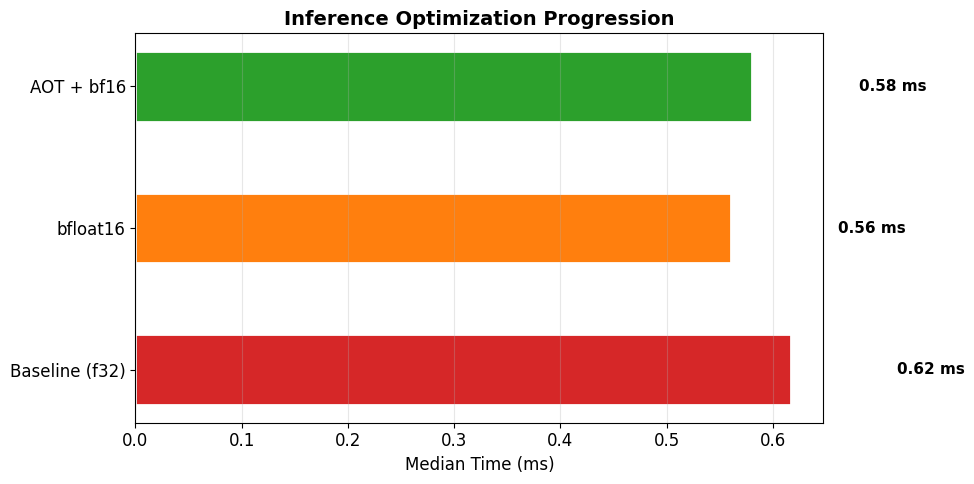

Overall speedup: 1.1x

Optimizations applied:
  1. bfloat16 parameters — 2x less memory, potentially faster compute
  2. AOT compilation — zero first-request latency
  3. (Buffer donation — shown conceptually; saves memory per step)
  4. (Static shape bucketing — prevents recompilation for variable inputs)

For production, also consider:
  • int8 weight quantization (Section 7)
  • Multi-device sharding (Notebook 05)
  • Custom kernels with Pallas (future notebook)


In [23]:
# @title Optimization Summary { display-mode: "form" }

fig, ax = plt.subplots(figsize=(10, 5))

labels = ['Baseline (f32)', 'bfloat16', 'AOT + bf16']
medians = [np.median(baseline_times), np.median(bf16_times), np.median(aot_times)]
colors = ['#d62728', '#ff7f0e', '#2ca02c']

bars = ax.barh(labels, medians, color=colors, height=0.5, edgecolor='white', linewidth=2)
ax.set_xlabel('Median Time (ms)', fontsize=12)
ax.set_title('Inference Optimization Progression', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add time labels on bars
for bar, val in zip(bars, medians):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} ms', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

speedup = medians[0] / medians[-1] if medians[-1] > 0 else float('inf')
print(f"Overall speedup: {speedup:.1f}x")
print(f"\nOptimizations applied:")
print(f"  1. bfloat16 parameters — 2x less memory, potentially faster compute")
print(f"  2. AOT compilation — zero first-request latency")
print(f"  3. (Buffer donation — shown conceptually; saves memory per step)")
print(f"  4. (Static shape bucketing — prevents recompilation for variable inputs)")
print(f"\nFor production, also consider:")
print(f"  • int8 weight quantization (Section 7)")
print(f"  • Multi-device sharding (Notebook 08)")
print(f"  • Custom kernels with Pallas (future notebook)")


## What's Next?

By now you have a strong grasp of JAX primitives, transformations, parallelization, and performance optimizations. However, manually tracking pytrees and writing raw training loops becomes tedious for extremely large models.

In **Notebook 06: Flax Basics**, we will shift higher up the stack. You will learn how to use Neural Network libraries (specifically Flax) which integrate cleanly with JAX to provide higher-level `Module` abstractions, dropping much of the boilerplate while retaining functional mathematical guarantees.
